# Exploratory Data Analysis (EDA)

This notebook explores the merged Lassa Fever forecasting dataset.

Objectives:

- Understand the structure of the merged dataset.
- Explore epidemiological trends.
- Explore weather variables.
- Detect missing values and anomalies.
- Identify seasonality and temporal patterns.
- Evaluate relationships between weather and confirmed cases.

The outputs from this notebook will guide feature engineering and model development.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from lassa_fever_forecast.config.paths import PROCESSED_DIR
from lassa_fever_forecast.data.loaders import load_csv

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [ ]:
forecast = load_csv(PROCESSED_DIR / "forecast_dataset.csv")

## Time Index Preparation

Time series models require temporal variables to be stored as datetime objects.

This section converts the weekly date columns into datetime format and orders the dataset chronologically.

In [ ]:
forecast["week_start_date"] = pd.to_datetime(forecast["week_start_date"])

forecast["week_end_date"] = pd.to_datetime(forecast["week_end_date"])

forecast = forecast.sort_values("week_start_date").reset_index(drop=True)

forecast.dtypes

In [ ]:
forecast.head()

In [ ]:
forecast.shape

In [ ]:
forecast.info()

In [ ]:
forecast.describe(include="all")

In [ ]:
forecast.isna().sum()

In [ ]:
forecast.duplicated().sum()

## Target Variable Exploration

The primary forecasting target is the weekly number of confirmed Lassa fever cases.

This section explores the distribution and temporal behaviour of the target variable before any modelling.

In [ ]:
forecast["confirmed_cases"].describe()

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    forecast["confirmed_cases"],
    bins=25,
)

plt.title("Distribution of Weekly Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Frequency")

plt.show()

## Weekly Confirmed Cases Over Time

This visualization shows the evolution of confirmed Lassa fever cases across epidemiological weeks.

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    forecast["week_start_date"],
    forecast["confirmed_cases"],
)

plt.title("Weekly Confirmed Lassa Fever Cases")

plt.xlabel("Week")

plt.ylabel("Confirmed Cases")

plt.grid(True)

plt.show()

## Suspected vs Confirmed Cases

Comparing suspected and confirmed cases helps assess whether the epidemiological signals move together over time.

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    forecast["week_start_date"],
    forecast["suspected_cases"],
    label="Suspected",
)

plt.plot(
    forecast["week_start_date"],
    forecast["confirmed_cases"],
    label="Confirmed",
)

plt.legend()

plt.grid(True)

plt.title("Suspected vs Confirmed Cases")

plt.show()

# Weather Variable Analysis

This section explores the weekly weather variables merged from NASA POWER.

Variables include:

- Temperature
- Precipitation
- Humidity
- Wind Speed

The objective is to understand their distributions and seasonal behaviour before feature engineering.

In [18]:
weather_columns = [
    "temperature",
    "precipitation",
    "humidity",
    "wind_speed",
]

forecast[weather_columns].describe()

,temperature,precipitation,humidity,wind_speed
count,313.000000,313.000000,313.000000,313.000000
mean,25.613894,22.379457,61.017335,2.168822
std,2.350341,37.717820,25.530809,0.984201
min,21.871429,0.000000,10.771429,0.998571
25%,23.640000,0.000000,36.298571,1.450000
50%,25.318571,9.930000,69.145714,1.837143
75%,27.141429,30.820000,85.472857,2.601429
max,31.750000,350.900000,91.797143,6.092857


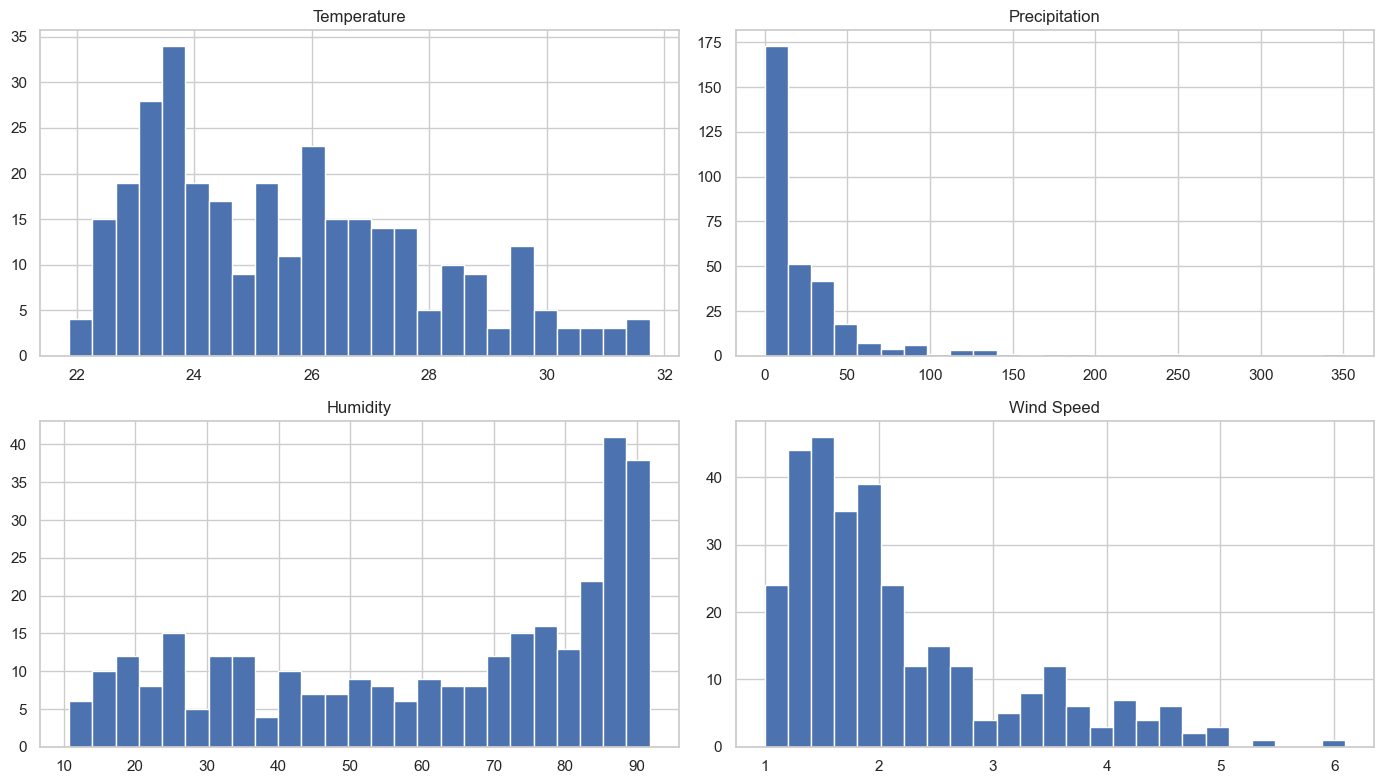

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, column in zip(
    axes.flatten(),
    weather_columns,
    strict=False,
):
    ax.hist(forecast[column], bins=25)
    ax.set_title(column.replace("_", " ").title())

plt.tight_layout()
plt.show()

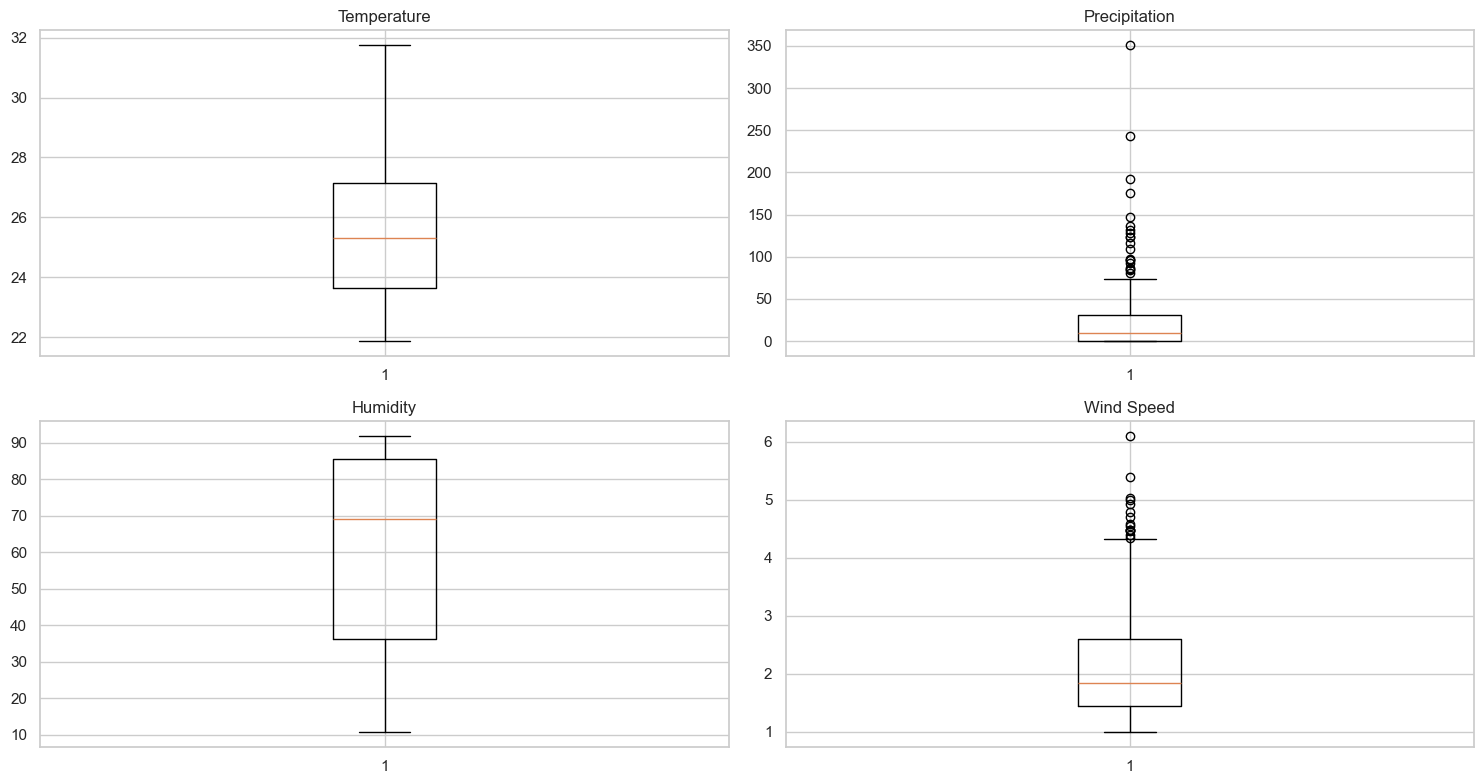

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

for ax, column in zip(
    axes.flatten(),
    weather_columns,
    strict=False,
):
    ax.boxplot(forecast[column])
    ax.set_title(column.replace("_", " ").title())

plt.tight_layout()
plt.show()

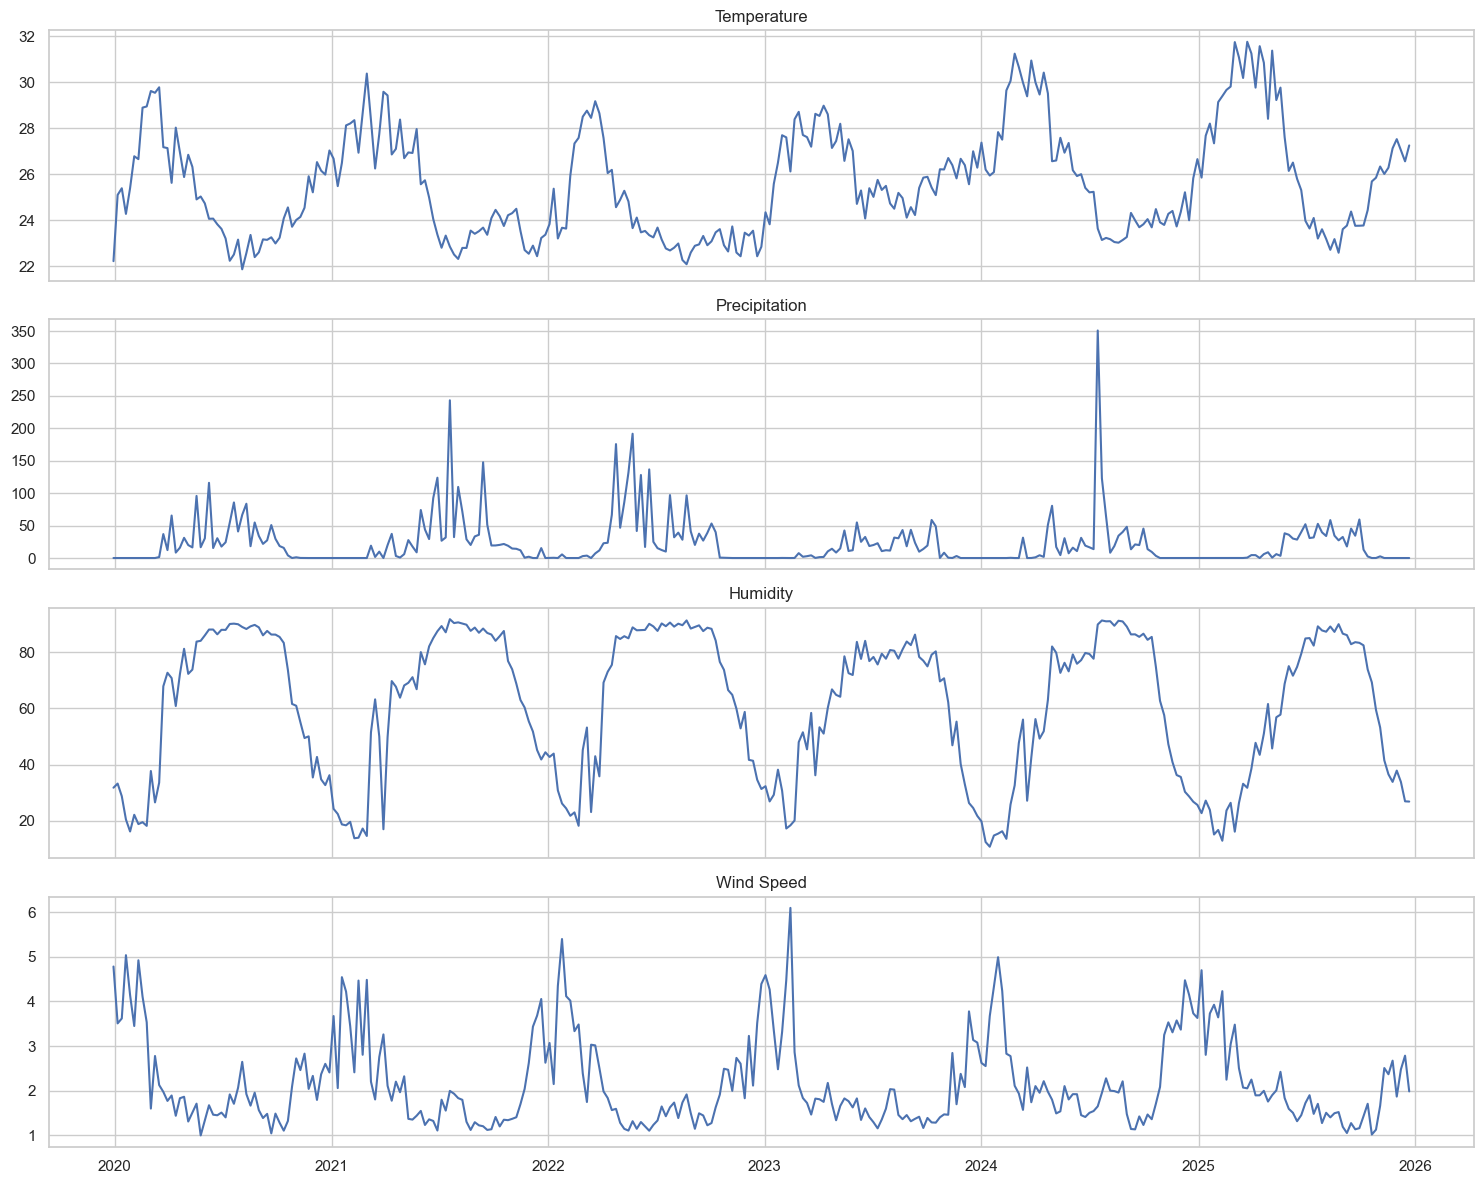

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

for ax, column in zip(
    axes.flatten(),
    weather_columns,
    strict=False,
):
    ax.plot(
        forecast["week_start_date"],
        forecast[column],
        linewidth=1.5,
    )
    ax.set_title(column.replace("_", " ").title())

plt.tight_layout()
plt.show()

# Relationship Between Weather and Confirmed Cases

We now examine whether weather variables exhibit visible relationships with weekly confirmed Lassa fever cases.

In [22]:
numeric_columns = [
    "confirmed_cases",
    "temperature",
    "precipitation",
    "humidity",
    "wind_speed",
]

forecast[numeric_columns].corr()

,confirmed_cases,temperature,precipitation,humidity,wind_speed
confirmed_cases,1.000000,0.351243,-0.305805,-0.678211,0.610708
temperature,0.351243,1.000000,-0.353736,-0.592029,0.203681
precipitation,-0.305805,-0.353736,1.000000,0.536024,-0.360157
humidity,-0.678211,-0.592029,0.536024,1.000000,-0.801294
wind_speed,0.610708,0.203681,-0.360157,-0.801294,1.000000
